In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Load the dataset
df = pd.read_csv("/content/Battery_dataset.csv")

# Define the target variable and feature engineering variables
y = df["RUL"]
df["power_ch"] = df["chV"] * df["chI"]
df["power_dis"] = df["disV"] * df["disI"]

df["temp_diff"] = df["chT"] - df["disT"]
df["current_diff"] = df["chI"] - df["disI"]
df["voltage_diff"] = df["chV"] - df["disV"]
X = df[
    [
        "cycle",
        "chI", "chV", "chT",
        "disI", "disV", "disT",
        "power_ch", "power_dis",
        "temp_diff", "current_diff", "voltage_diff"
    ]
]

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)        # ✅ no leakage
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "n_estimators": [100, 200]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

rf_grid.fit(X_train_scaled, y_train)
gb = GradientBoostingRegressor(random_state=42)

gb_param_grid = {
    "learning_rate": [0.01, 0.1, 0.5],
    "n_estimators": [100, 200],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    gb,
    gb_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

gb_grid.fit(X_train_scaled, y_train)
rf = rf_grid.best_estimator_ if rf_grid.best_score_ > gb_grid.best_score_ else gb_grid.best_estimator_

y_pred_rf = rf.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random forest:", rf)
print("MSE:", mse_rf)
print("R2:", r2_rf)

Random forest: RandomForestRegressor(max_depth=3, random_state=42)
MSE: 313.45606138029484
R2: 0.9166595838111938


MSE (KNN):  1049.3270588235296


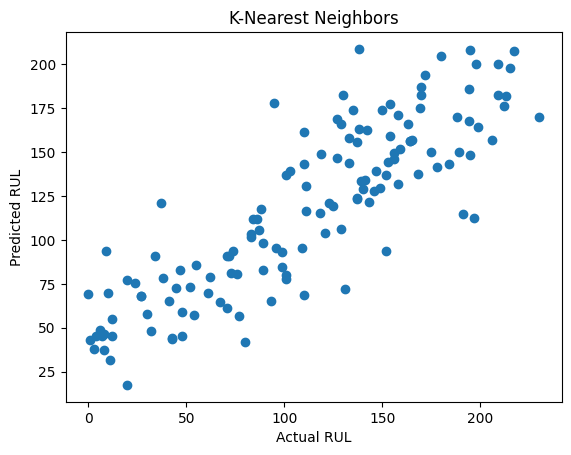

MSE: 1049.3270588235296
R2: 0.7210092112577462


In [33]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Train a KNN regression model
model_knn = KNeighborsRegressor(n_neighbors=5)

model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

# Calculate MSE for KNN
mse_knn = mean_squared_error(y_test, y_pred_knn)
print("MSE (KNN): ", mse_knn)

# Create a plot for KNN
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("K-Nearest Neighbors")
plt.show()

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("MSE:", mse_knn)
print("R2:", r2_knn)

MSE (Linear Regression):  267.64904902423615


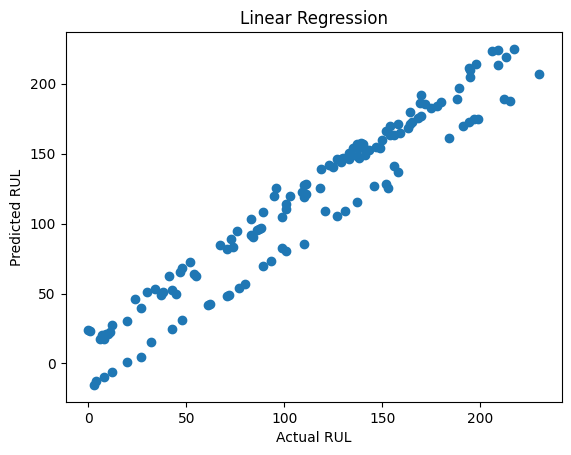

MSE: 267.64904902423615
R2: 0.9288385649969751


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Train a linear regression model
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)


# Calculate MSE for linear regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
print("MSE (Linear Regression): ", mse_lr)

# Create a plot for linear regression
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression")
plt.show()
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("MSE:", mse_lr)
print("R2:", r2_lr)

MSE (Decision Tree):  784.9558823529412
R2: 0.7912991389061774


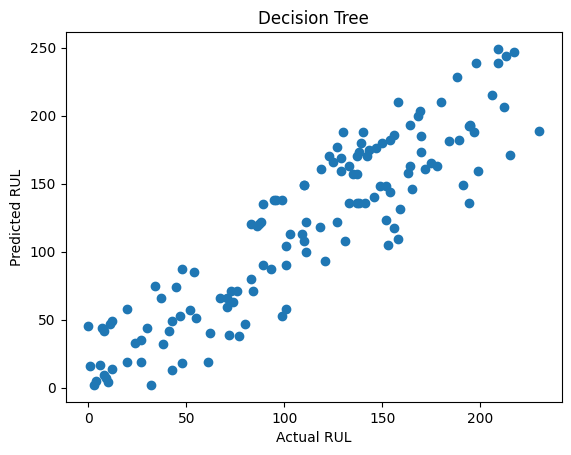

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Train a decision tree model
model_dt = DecisionTreeRegressor()
model_dt.fit(X_train_scaled, y_train)
y_pred_dt = model_dt.predict(X_test_scaled)

# Calculate MSE for decision tree
mse_dt = mean_squared_error(y_test, y_pred_dt)
print("MSE (Decision Tree): ", mse_dt)

mse = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)


print("R2:", r2_dt)
# Create a plot for decision tree
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Decision Tree")
plt.show()

In [36]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)

xgb_param_grid = {
    "max_depth":      [3, 5, 7],
    "learning_rate":  [0.01, 0.1, 0.2],
    "n_estimators":   [100, 200, 300],
    "subsample":      [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,        # use all CPU cores
    verbose=1
)

xgb_grid.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_grid.best_estimator_.predict(X_test_scaled)

print("Best XGBoost params:", xgb_grid.best_params_)


mse_xgb  = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"RMSE : {rmse_xgb:.2f}")
print(f"MSE  : {mse_xgb:.2f}")
print(f"R²   : {r2_xgb:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
RMSE : 18.01
MSE  : 324.28
R²   : 0.9138


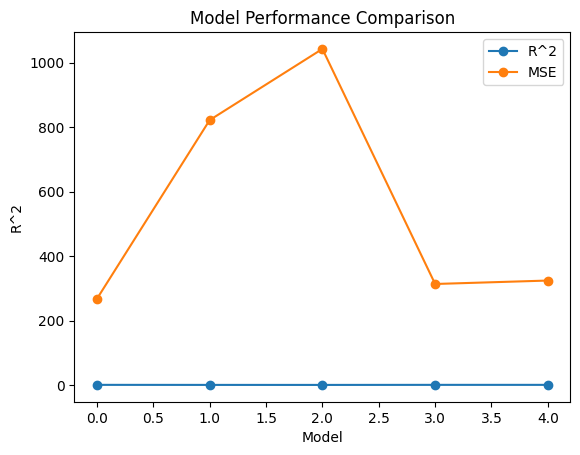

In [27]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the R^2 values for each model
ax.plot([r2_lr, r2_dt, r2_knn, r2_rf, r2_xgb], marker='o', linestyle='-', label='R^2')

# Add a title and labels to the graph
ax.set_title('Model Performance Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('R^2')

# Plot the MSE values for each model
ax.plot([mse_lr, mse_dt, mse_knn, mse_rf, mse_xgb], marker='o', linestyle='-', label='MSE')

# Add a legend to the graph
ax.legend(loc='upper right')

# Show the graph
plt.show()

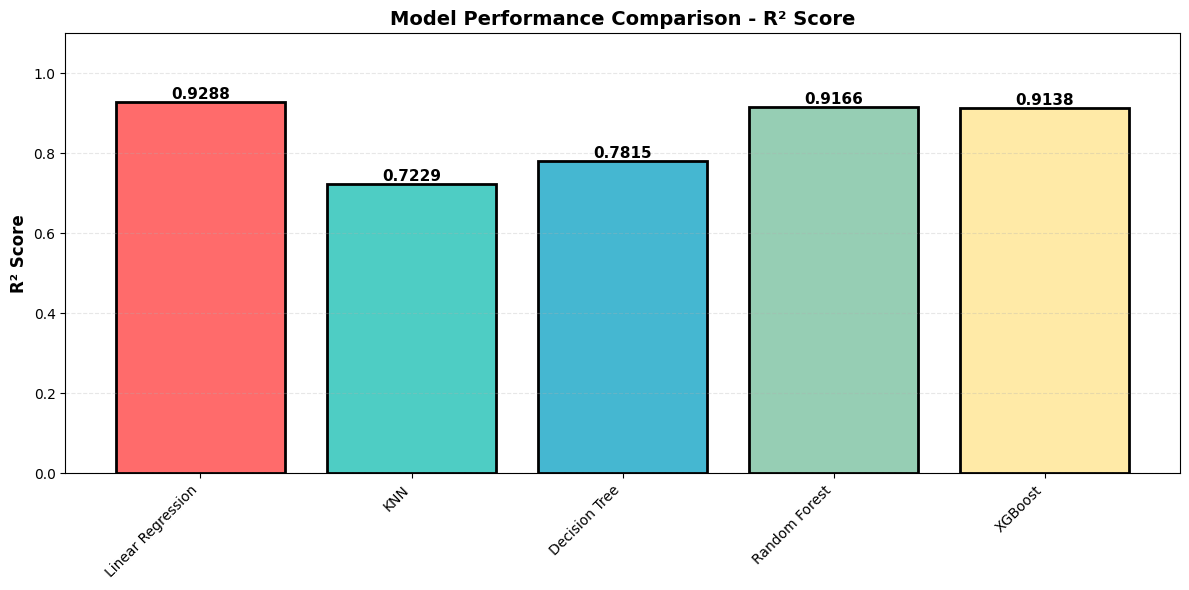

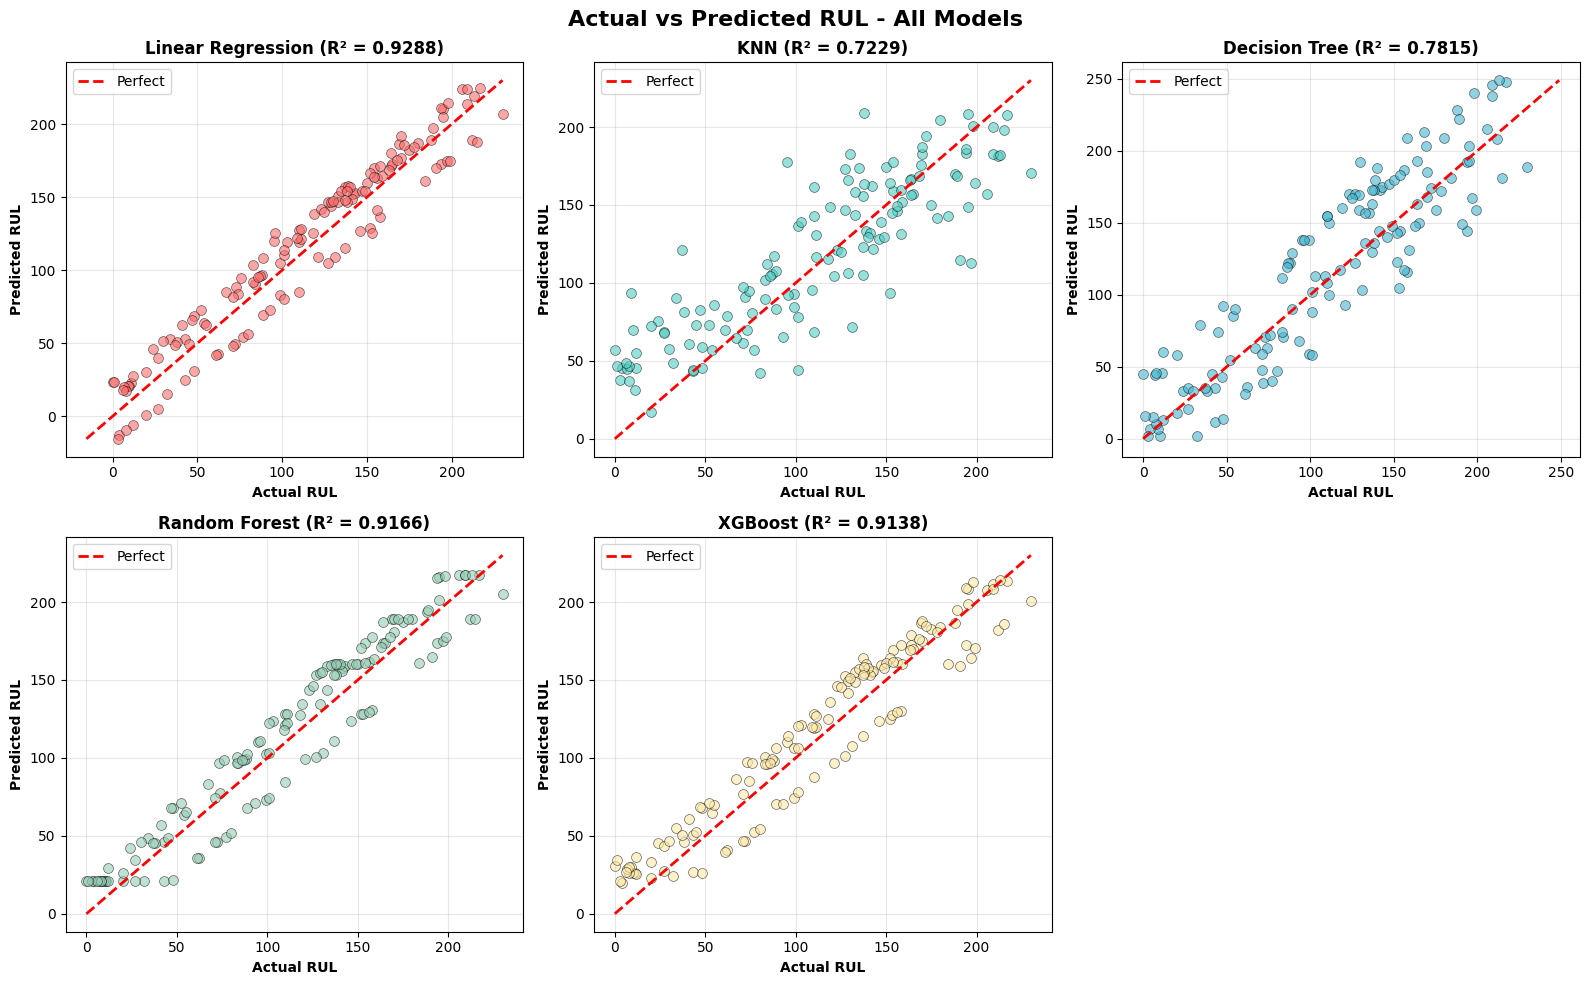

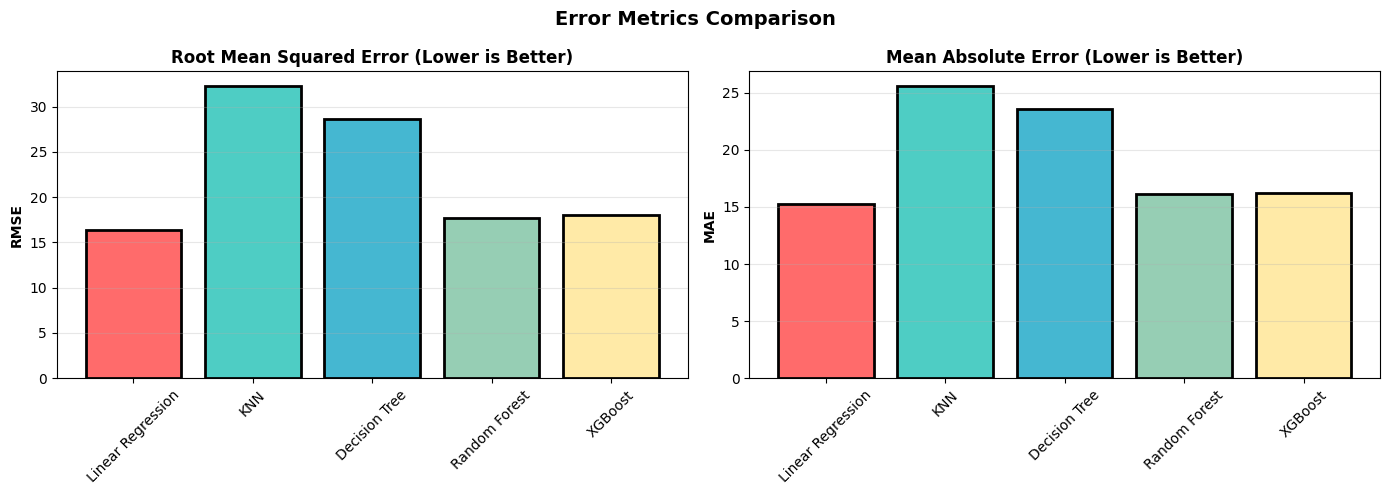

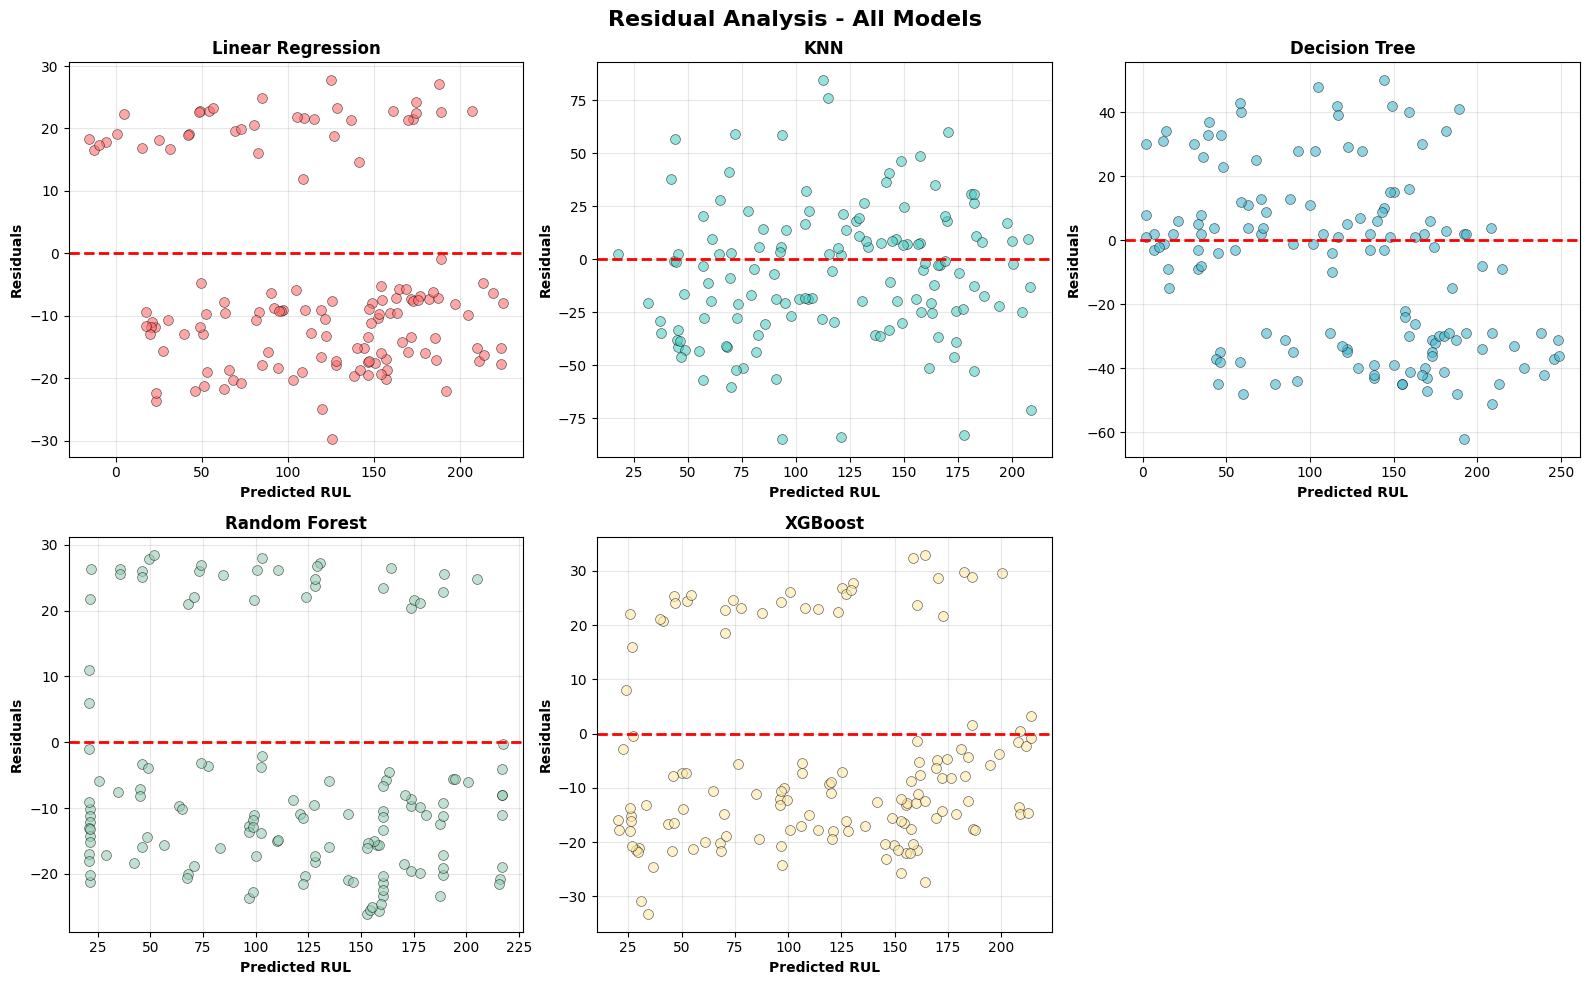


MODEL PERFORMANCE SUMMARY
            Model  R² Score      RMSE       MAE
Linear Regression  0.928839 16.359983 15.225935
              KNN  0.722872 32.285013 25.604412
    Decision Tree  0.781532 28.665156 23.588235
    Random Forest  0.916609 17.710075 16.129877
          XGBoost  0.913781 18.007809 16.192070

🏆 BEST MODEL: Linear Regression
   R² Score: 0.9288
   RMSE: 16.36
   MAE: 15.23


In [29]:
"""
MINIMAL GRAPHING CODE - Just 5 Essential Graphs
Copy-paste directly into your Jupyter notebook after training models
"""

# ============================================================================
# ADD THIS AT THE TOP OF YOUR NOTEBOOK
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
models = ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost']

# ============================================================================
# GRAPH 1: R² Score Comparison (Most Important)
# ============================================================================

# Calculate R² for all models
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_knn),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb)
]

# Create bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(models, r2_scores, color=colors, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison - R² Score', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================================
# GRAPH 2: Actual vs Predicted (All Models)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Actual vs Predicted RUL - All Models', fontsize=16, fontweight='bold')

predictions = [
    (y_pred_lr, 'Linear Regression', r2_scores[0]),
    (y_pred_knn, 'KNN', r2_scores[1]),
    (y_pred_dt, 'Decision Tree', r2_scores[2]),
    (y_pred_rf, 'Random Forest', r2_scores[3]),
    (y_pred_xgb, 'XGBoost', r2_scores[4]),
]

axes = axes.flatten()

for idx, (y_pred, name, r2) in enumerate(predictions):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, s=50, color=colors[idx], edgecolors='black', linewidth=0.5)

    # Add diagonal line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')

    ax.set_xlabel('Actual RUL', fontweight='bold')
    ax.set_ylabel('Predicted RUL', fontweight='bold')
    ax.set_title(f'{name} (R² = {r2:.4f})', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].remove()
plt.tight_layout()
plt.show()

# ============================================================================
# GRAPH 3: RMSE & MAE Comparison
# ============================================================================

# Calculate metrics
rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_xgb))
]

mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_knn),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf),
    mean_absolute_error(y_test, y_pred_xgb)
]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Metrics Comparison', fontsize=14, fontweight='bold')

# RMSE
axes[0].bar(models, rmse_scores, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel('RMSE', fontweight='bold')
axes[0].set_title('Root Mean Squared Error (Lower is Better)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# MAE
axes[1].bar(models, mae_scores, color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylabel('MAE', fontweight='bold')
axes[1].set_title('Mean Absolute Error (Lower is Better)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================================
# GRAPH 4: Residual Plots (Show Model Errors)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Residual Analysis - All Models', fontsize=16, fontweight='bold')

residuals_all = [
    (y_test - y_pred_lr, y_pred_lr),
    (y_test - y_pred_knn, y_pred_knn),
    (y_test - y_pred_dt, y_pred_dt),
    (y_test - y_pred_rf, y_pred_rf),
    (y_test - y_pred_xgb, y_pred_xgb),
]

axes = axes.flatten()

for idx, (resid, pred) in enumerate(residuals_all):
    ax = axes[idx]
    ax.scatter(pred, resid, alpha=0.6, s=50, color=colors[idx], edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', lw=2)
    ax.set_xlabel('Predicted RUL', fontweight='bold')
    ax.set_ylabel('Residuals', fontweight='bold')
    ax.set_title(models[idx], fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].remove()
plt.tight_layout()
plt.show()

# ============================================================================
# GRAPH 5: Performance Summary Table
# ============================================================================

import pandas as pd

# Create summary table
summary = pd.DataFrame({
    'Model': models,
    'R² Score': r2_scores,
    'RMSE': rmse_scores,
    'MAE': mae_scores,
})

print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

# Find best model
best_idx = summary['R² Score'].idxmax()
best_model = summary.loc[best_idx, 'Model']
best_r2 = summary.loc[best_idx, 'R² Score']

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   RMSE: {summary.loc[best_idx, 'RMSE']:.2f}")
print(f"   MAE: {summary.loc[best_idx, 'MAE']:.2f}")
print("="*80)
